<a href="https://colab.research.google.com/github/balasri03/Mini_project/blob/main/review_covid19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Preprocessing**

In [ ]:
import re
import torch
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import pandas as pd
import time
from collections import Counter
import numpy as np


In [ ]:
train_df = pd.read_csv("C19_train.csv")
val_df = pd.read_csv("C19_val.csv")
test_df = pd.read_csv("C19_test.csv")

In [ ]:
train_df.shape

(4533, 6)

In [ ]:
print(train_df["Stance 1"].value_counts())

Stance 1
NONE       1627
FAVOR      1464
AGAINST    1442
Name: count, dtype: int64


In [ ]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

4533
800
800


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)          # remove URLs
    text = re.sub(r"@\w+", "", text)                    # remove mentions
    text = re.sub(r"#", "", text)                       # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)                # keep only letters
    text = re.sub(r"\s+", " ", text).strip()            # remove extra spaces
    return text

In [ ]:
train_df["clean_text"] = train_df["Tweet"].apply(clean_text)
val_df["clean_text"] = val_df["Tweet"].apply(clean_text)
test_df["clean_text"] = test_df["Tweet"].apply(clean_text)

In [ ]:
from collections import Counter

def build_vocab(texts, min_freq=5):
    counter = Counter()

    for text in texts:
        words = text.split()
        counter.update(words)

    vocab = {"<pad>":0, "<unk>":1}

    for word,freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab


In [ ]:
def text_to_seq(text, vocab):
    words = text.split()

    return [
        vocab.get(word, vocab["<unk>"])
        for word in words
    ]


In [ ]:
train_df["input_text"] = train_df["clean_text"] + " " + train_df["Target 1"].apply(clean_text)
val_df["input_text"]   = val_df["clean_text"]   + " " + val_df["Target 1"].apply(clean_text)
test_df["input_text"]  = test_df["clean_text"]  + " " + test_df["Target 1"].apply(clean_text)
vocab = build_vocab(train_df["input_text"].tolist())
print(f"Vocab size: {len(vocab)}")

Vocab size: 2256


In [ ]:
len(train_df['input_text'])

4533

In [ ]:

label_col = "Stance 1"
unique_labels = sorted(train_df[label_col].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {v: k for k, v in label2id.items()}

print("Label mapping:", label2id)

Label mapping: {'AGAINST': 0, 'FAVOR': 1, 'NONE': 2}


In [ ]:
print(label2id)
print(val_df["Stance 1"].unique())
print(train_df["input_text"].head(10))

{'AGAINST': 0, 'FAVOR': 1, 'NONE': 2}
['FAVOR' 'AGAINST' 'NONE']
0    surgeons amp nurses wear them for hours every ...
1    i try to be unbiased on my twitter which is wh...
2    so out of members of congress with covid is a ...
3    im in coach f en route to london euston from s...
4    when you wear a mask wear it correctly cover y...
5    omg people say i have to wear a mask and im cr...
6    a cute girl told me she loved my mask today i ...
7    employee correct mask wearing customer mask we...
8    what a bunch of hillbillies that asshole is pr...
9    whats schantz the democrat governors of wa and...
Name: input_text, dtype: object


In [ ]:
train = train_df["input_text"]
len(train)

4533

In [ ]:
test = test_df["input_text"]
len(test)

800

In [ ]:
val = val_df["input_text"]
len(val)

800

**LSTM Baseline**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import Input, Embedding
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import SpatialDropout1D

In [ ]:
model = Sequential()

model.add(Embedding(len(vocab), 128))
model.add(SpatialDropout1D(0.3))

model.add(LSTM(64))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(3, activation="softmax"))

In [ ]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
X_train_seq = [text_to_seq(text, vocab) for text in train_df["input_text"]]
X_val_seq = [text_to_seq(text, vocab) for text in val_df["input_text"]]
y_train = np.array([label2id[label] for label in train_df["Stance 1"]])
y_val = np.array([label2id[label] for label in val_df["Stance 1"]])
all_sequences = X_train_seq + X_val_seq
max_sequence_length = 40

In [ ]:
print(len(y_train))
print(len(y_val))

4533
800


In [ ]:
X_train_padded = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post', value=vocab["<pad>"])
X_val_padded = pad_sequences(X_val_seq, maxlen=max_sequence_length, padding='post', value=vocab["<pad>"])
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)


In [ ]:
len(X_train_padded)

4533

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0478502080443828), 1: np.float64(1.032103825136612), 2: np.float64(0.9287031346035648)}


In [ ]:
import time
strat_time = time.time()
model.fit(
    X_train_padded,
    y_train,
    epochs=25,
    batch_size=16,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stop]
)
end_time = time.time()


Epoch 1/25
 18/284 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.3794 - loss: 1.0955

KeyboardInterrupt: 

In [ ]:
X_test_seq = [text_to_seq(text, vocab) for text in test_df["input_text"]]

y_test = np.array([label2id[label] for label in test_df["Stance 1"]])

In [ ]:
X_test_pad = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding="post")

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Convert labels to numpy
y_test = np.array(y_test)

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Predict probabilities
y_pred_prob = model.predict(X_test_pad)

# Number of classes
n_classes = 3

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,7))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label="Class %d (AUC = %0.4f)" % (i, roc_auc[i]))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM Baseline")
plt.legend(loc="lower right")

plt.show()

In [ ]:
X_test_seq = [text_to_seq(text, vocab) for text in test]

X_test_padded = pad_sequences(
    X_test_seq,
    maxlen=max_sequence_length,
    padding='post',
    value=vocab["<pad>"]
)

In [ ]:
# Predictions
start_infer = time.time()
prediction = model.predict(X_test_padded)
end_infer = time.time()
# Convert probabilities to labels
y_pred = prediction.argmax(axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix

val_predictions = model.predict(X_val_padded)
y_val_pred = np.argmax(val_predictions, axis=1)

cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
params = model.count_params()
infer_time_seconds = end_infer - start_infer
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Parameters (M):", params/1e6)
print("Training time: ", end_time - strat_time)
print("Inference Time (seconds):", infer_time_seconds)

**LSTM + OHE**

In [ ]:
len(train)

In [ ]:
len(test)

In [ ]:
len(val)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Lambda, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Lambda
from tensorflow.keras.regularizers import l2

vocab_size = len(vocab)
model_ohe = Sequential()
model_ohe.add(
    Lambda(
        lambda x: tf.one_hot(tf.cast(x, tf.int32), depth=vocab_size),
        input_shape=(max_sequence_length,)
    )
)
model_ohe.add(
    LSTM(
        24,
        return_sequences=True,
        kernel_regularizer=l2(0.0005),
        recurrent_dropout=0.2
    )
)
model_ohe.add(Dropout(0.4))
model_ohe.add(
    LSTM(
        24,
        kernel_regularizer=l2(0.0005),
        recurrent_dropout=0.2
    )
)
model_ohe.add(Dropout(0.4))
model_ohe.add(Dense(3, activation="softmax"))

In [ ]:
model_ohe.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
'balanced',
classes=np.unique(y_train),
y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

In [ ]:
import time
start_time = time.time()
model_ohe.fit(
X_train_padded,
y_train,
epochs=25,
validation_data=(X_val_padded,y_val),
callbacks=[early_stop],
class_weight=class_weights
)
end_time = time.time()

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

In [ ]:
start_infer_time=time.time()
val_predictions = model_ohe.predict(X_val_padded)
end_infer_time=time.time()
y_val_pred_ohe = np.argmax(val_predictions, axis=1)

In [ ]:
cm = confusion_matrix(y_val, y_val_pred_ohe)

print("Confusion Matrix:")
print(cm)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_val_pred_ohe)
precision = precision_score(y_val, y_val_pred_ohe, average='macro')
recall = recall_score(y_val, y_val_pred_ohe, average='macro')
f1 = f1_score(y_val, y_val_pred_ohe, average='macro')
model_time=end_time-start_time
infer_tine=end_infer_time-start_infer_time
params = model_ohe.count_params()
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Training Time",model_time)
print("infer time",infer_tine)
print("Parameters (M):", params/1e6)

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
y_val_bin = label_binarize(y_val, classes=[0,1,2])

In [ ]:
y_pred_prob = model_ohe.predict(X_val_padded)

In [ ]:
# Store ROC values
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC for each class
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(7,7))

plt.plot(fpr[0], tpr[0], label=f"Class 0 (AUC = {roc_auc[0]:.3f})")
plt.plot(fpr[1], tpr[1], label=f"Class 1 (AUC = {roc_auc[1]:.3f})")
plt.plot(fpr[2], tpr[2], label=f"Class 2 (AUC = {roc_auc[2]:.3f})")

# Random classifier line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM One Hot Encoding Model")
plt.legend(loc="lower right")

plt.grid(True)
plt.show()

**LSTM + GloVe**

In [ ]:
!pip install gensim
import gensim.downloader as api

glove_model = api.load("glove-wiki-gigaword-100")

In [ ]:
vector = glove_model["vaccine"]

print(vector.shape)

In [ ]:
vocab_size = len(vocab)
embedding_dim = 100

In [ ]:
vocab_size

In [ ]:
import numpy as np

embedding_matrix = np.zeros((vocab_size, embedding_dim))

hits = 0
misses = 0

for word, idx in vocab.items():

    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hits += 1
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))
        misses += 1

print("Converted:", hits)
print("Missed:", misses)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

model_glove = Sequential()

model_glove.add(
Embedding(
vocab_size,
embedding_dim,
weights=[embedding_matrix],
input_length=max_sequence_length,
trainable=True
))


model_glove.add(SpatialDropout1D(0.4))

model_glove.add(LSTM(64, return_sequences=True))

model_glove.add(Dropout(0.4))

model_glove.add(LSTM(32))

model_glove.add(Dropout(0.4))

model_glove.add(Dense(3, activation="softmax"))

model_glove.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
class_weights = {
    0: 1.8,   # AGAINST (increase focus)
    1: 1.5,   # FAVOR
    2: 1.0    # NONE
}

print(class_weights)

In [ ]:

start_train = time.time()
model_glove.fit(
X_train_padded,
y_train,
validation_data=(X_val_padded,y_val),
epochs=25,
batch_size=16,
callbacks=[early_stop],
class_weight=class_weights
)

end_train = time.time()

training_time = (end_train - start_train) / 3600

In [ ]:
from sklearn.metrics import confusion_matrix
start_inf = time.time()
pred = model_glove.predict(X_val_padded)

end_inf = time.time()

inference_time = end_inf - start_inf
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(y_val, y_pred)

print(cm)

In [ ]:
print(X_val_padded.shape)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to binary
y_val_bin = label_binarize(y_val, classes=[0,1,2])

n_classes = 3

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], pred[:, i])

    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure()

colors = ['blue', 'red', 'green']
class_names = ['AGAINST', 'FAVOR', 'NONE']

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - GloVe LSTM')

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)

precision = precision_score(y_val, y_pred, average="macro")

recall = recall_score(y_val, y_pred, average="macro")

f1 = f1_score(y_val, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Inference Time (seconds):", inference_time)
print("Training Time (hours):", training_time)
params = model_glove.count_params()

print("Total Parameters:", params)

print("Parameters (Millions):", params/1e6)

**LSTM + GloVe + atenction**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True)

        self.b = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True)

        self.u = self.add_weight(
            shape=(input_shape[-1],),
            initializer="glorot_uniform",
            trainable=True)

    def call(self, inputs):

        score = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)

        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=1),
            axis=1)

        context_vector = attention_weights[..., tf.newaxis] * inputs

        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

model_attention = Sequential()

# GloVe Embedding Layer
model_attention.add(
    Embedding(
        vocab_size,
        embedding_dim,
        weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=True
    )
)

# Dropout for embedding
model_attention.add(SpatialDropout1D(0.3))

# LSTM layer (NOT Bidirectional)
model_attention.add(
    LSTM(
        64,
        return_sequences=True
    )
)

# Attention Layer
model_attention.add(AttentionLayer())

# Dropout
model_attention.add(Dropout(0.5))

# Output Layer
model_attention.add(Dense(3, activation="softmax"))

# Compile model
model_attention.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
class_weights = {0:2.0, 1:1.0, 2:1.0}

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

start_train = time.time()
history = model_attention.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights
)

end_train = time.time()

training_time = (end_train - start_train) / 3600

Epoch 1/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.4589 - loss: 1.2347 - val_accuracy: 0.4875 - val_loss: 0.9784
Epoch 2/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.5257 - loss: 1.1546 - val_accuracy: 0.5800 - val_loss: 0.8973
Epoch 3/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.6038 - loss: 1.0510 - val_accuracy: 0.6025 - val_loss: 0.8692
Epoch 4/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.6508 - loss: 0.9542 - val_accuracy: 0.5625 - val_loss: 0.9650
Epoch 5/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6984 - loss: 0.8686 - val_accuracy: 0.6212 - val_loss: 0.9286
Epoch 6/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7333 - loss: 0.7920 - val_accuracy: 0.6150 - val_loss: 0.8881
Epoch 7/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.7584 - loss: 0.7302 - val_accuracy: 0.6237 - val_loss: 0.9465
Epoch 8/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.7812 - loss: 0.6622 - v

In [ ]:
from sklearn.metrics import confusion_matrix
start_inf = time.time()
pred = model_attention.predict(X_val_padded)
end_inf = time.time()
y_pred = pred.argmax(axis=1)

print(confusion_matrix(y_val, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[136  62  45]
 [ 47 193  23]
 [ 61  61 172]]


In [ ]:
from sklearn.preprocessing import label_binarize

# Binarize labels
y_val_bin = label_binarize(y_val, classes=[0,1,2])

In [ ]:
from sklearn.metrics import roc_curve, auc

n_classes = 3

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], pred[:, i])

    roc_auc[i] = auc(fpr[i], tpr[i])

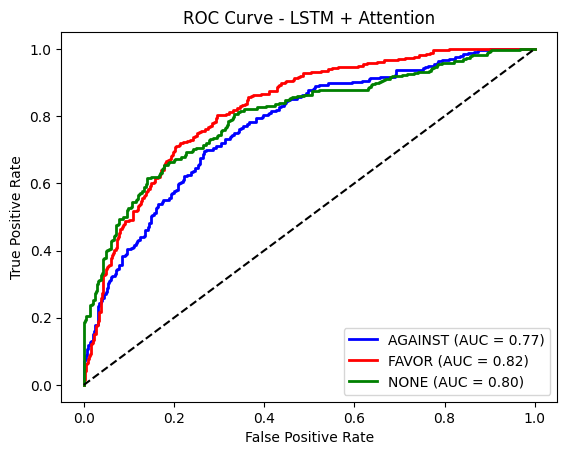

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

colors = ['blue', 'red', 'green']
class_names = ['AGAINST', 'FAVOR', 'NONE']

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        lw=2,
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

# diagonal linec
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - LSTM + Attention')

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)

precision = precision_score(y_val, y_pred, average="macro")

recall = recall_score(y_val, y_pred, average="macro")

f1 = f1_score(y_val, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("Training Time (hours):", training_time)
inference_time = end_inf - start_inf

print("Inference Time (seconds):", inference_time)
params = model_attention.count_params()

print("Total Parameters:", params)

print("Parameters (Millions):", params/1e6)

Accuracy: 0.62625
Precision: 0.6282677365059602
Recall: 0.6261816998936519
F1 Score: 0.6231276612653075
Training Time (hours): 0.04751604848437839
Inference Time (seconds): 0.3658902645111084
Total Parameters: 272259
Parameters (Millions): 0.272259


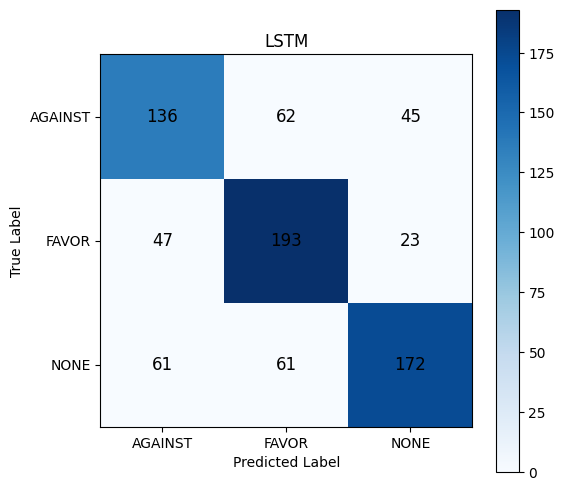

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Class labels
class_names = ['AGAINST', 'FAVOR', 'NONE']

# Create a blank white matrix
display_matrix = np.zeros_like(cm)

# Put only diagonal values
for i in range(len(cm)):
    display_matrix[i, i] = cm[i, i]

# Plot
plt.figure(figsize=(6,6))

# Show only diagonal in blue
plt.imshow(display_matrix, cmap='Blues')

# Add text annotations (ALL values, not just diagonal)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='black',
            fontsize=12
        )

# Labels
plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LSTM")

# Grid lines
plt.grid(False)

plt.colorbar()

plt.show()

**GRU**


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, SpatialDropout1D

In [ ]:
model_gru = Sequential()

model_gru.add(
    Embedding(
        input_dim=len(vocab),
        output_dim=100,
        input_length=max_sequence_length
    )
)

model_gru.add(SpatialDropout1D(0.4))

model_gru.add(
    GRU(
        64,
        return_sequences=True,
        recurrent_dropout=0.2
    )
)

model_gru.add(Dropout(0.4))

model_gru.add(
    GRU(
        32,
        recurrent_dropout=0.2
    )
)

model_gru.add(Dropout(0.4))

model_gru.add(Dense(3, activation="softmax"))

In [ ]:
model_gru.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:

start_train = time.time()
model_gru.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights
)
end_train = time.time()

training_time = (end_train - start_train) / 3600

In [ ]:
y_test = np.array([label2id[label] for label in test_df["Stance 1"]])

In [ ]:
X_test_seq = [text_to_seq(text, vocab) for text in test_df["input_text"]]

X_test_pad = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding="post")

In [ ]:
X_test_seq = [text_to_seq(text, vocab) for text in test_df["input_text"]]

X_test_pad = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding="post")

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Convert test labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Predict probabilities using GRU model
start_inf = time.time()
y_pred_prob = model_gru.predict(X_test_pad)
end_inf = time.time()
inference_time = end_inf - start_inf
# Store ROC values
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC for each class
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
plt.figure(figsize=(7,7))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — GRU Baseline")
plt.legend(loc="lower right")

plt.show()

NameError: name 'model_gru' is not defined

In [ ]:

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("Training Time (hours):", training_time)

print("Inference Time (seconds):", inference_time)
params = model_gru.count_params()

print("Total Parameters:", params)

print("Parameters (Millions):", params / 1e6)

**GRU + GloVe**

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

In [ ]:
vocab_size = len(vocab)

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, SpatialDropout1D

vocab_size = len(vocab)
embedding_dim = 100
max_sequence_length = 50
model_glove_gru = Sequential()

model_glove_gru.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=True
    )
)

model_glove_gru.add(SpatialDropout1D(0.4))

model_glove_gru.add(
    GRU(
        64,
        return_sequences=True,
        recurrent_dropout=0.2
    )
)

model_glove_gru.add(Dropout(0.4))

model_glove_gru.add(
    GRU(
        32,
        recurrent_dropout=0.2
    )
)

model_glove_gru.add(Dropout(0.4))

model_glove_gru.add(Dense(3, activation="softmax"))


In [ ]:
model_glove_gru.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
start_train = time.time()
model_glove_gru.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights
)

end_train = time.time()

training_time = (end_train - start_train) / 3600

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Predict probabilities
start_inf = time.time()
y_pred_prob = model_glove_gru.predict(X_test_pad)
end_inf = time.time()

inference_time = end_inf - start_inf
# Store values
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC for each class
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(7,6))

plt.plot(fpr[0], tpr[0], label="Negative (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Positive (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Other (AUC = %0.2f)" % roc_auc[2])

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - COVID19 Sentiment Model")

plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="macro")

recall = recall_score(y_test, y_pred, average="macro")

f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
params = model_glove_gru.count_params()
print("Training Time (hours):", training_time)
print("Inference Time (seconds):", inference_time)
print("Total Parameters:", params)

print("Parameters (Millions):", params/1e6)

In [ ]:
import numpy as np

y_pred = np.argmax(y_pred_prob, axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive", "Other"],
    yticklabels=["Negative", "Positive", "Other"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - GRU Model")

plt.show()

**GRU + Attention**

In [ ]:
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=True
))

model.add(SpatialDropout1D(0.3))

model.add(GRU(64, return_sequences=True, recurrent_dropout=0.2))

model.add(AttentionLayer())

model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))

model.add(Dropout(0.4))

model.add(Dense(3, activation="softmax"))

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.0005),
    metrics=["accuracy"]
)

In [ ]:
model_attention_gru.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
# from sklearn.utils.class_weight import compute_class_weight

# weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# class_weights = dict(enumerate(weights))
class_weights = {
    0: 1.5,   # Negative ↑ (important)
    1: 1.0,
    2: 1.2
}

In [ ]:

start_train = time.time()
history_gru = model_attention_gru.fit(
    X_train_padded,

    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights   # 👈 HERE
)
end_train = time.time()
training_time = (end_train - start_train) / 3600


Epoch 1/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 68s 168ms/step - accuracy: 0.6349 - loss: 0.9717 - val_accuracy: 0.6087 - val_loss: 0.8581
Epoch 2/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 44s 155ms/step - accuracy: 0.6883 - loss: 0.8668 - val_accuracy: 0.6162 - val_loss: 0.8503
Epoch 3/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 34s 119ms/step - accuracy: 0.7384 - loss: 0.7598 - val_accuracy: 0.5975 - val_loss: 0.9234
Epoch 4/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 30s 105ms/step - accuracy: 0.7809 - loss: 0.6567 - val_accuracy: 0.6162 - val_loss: 0.9597
Epoch 5/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 38s 93ms/step - accuracy: 0.8114 - loss: 0.5709 - val_accuracy: 0.6100 - val_loss: 1.0157
Epoch 6/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 29s 101ms/step - accuracy: 0.8374 - loss: 0.4985 - val_accuracy: 0.5962 - val_loss: 1.1255


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


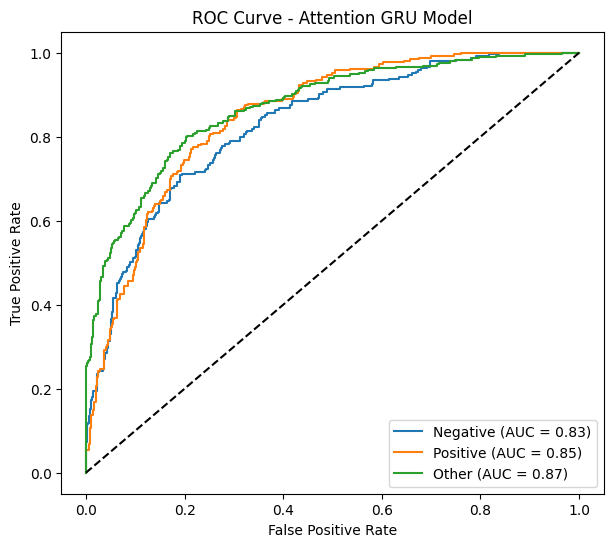

In [ ]:
# ROC Curve for Attention GRU Model

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Step 1: Convert labels to binary (for 3 classes)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Step 2: Predict probabilities
start_inf = time.time()
y_pred_prob = model_attention_gru.predict(X_test_pad)
end_inf = time.time()
inference_time = end_inf - start_inf
# Step 3: Store ROC values
fpr = {}
tpr = {}
roc_auc = {}

# Step 4: Compute ROC for each class
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 5: Plot ROC curves
plt.figure(figsize=(7,6))

plt.plot(fpr[0], tpr[0], label="Negative (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Positive (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Other (AUC = %0.2f)" % roc_auc[2])

# Random classifier line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Attention GRU Model")

plt.legend(loc="lower right")
plt.show()

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

y_pred_prob = model_attention_gru.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


In [ ]:
cm = confusion_matrix(y_test, y_pred)

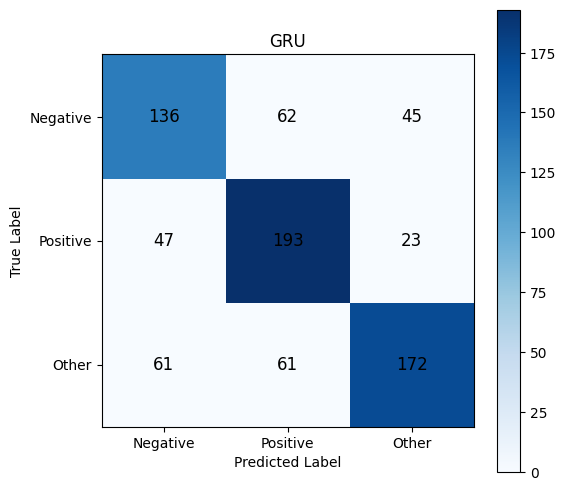

In [ ]:
# plt.figure(figsize=(6,5))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues",   # light color theme
#     xticklabels=["Negative", "Positive", "Other"],
#     yticklabels=["Negative", "Positive", "Other"]
# )

# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("GRU")

# plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Step 1: Compute confusion matrix (use test or val consistently)
cm = confusion_matrix(y_test, y_pred)

# Step 2: Class labels (change as needed)
class_names = ["Negative", "Positive", "Other"]

# Step 3: Create diagonal-only matrix
diag_matrix = np.zeros_like(cm)

for i in range(len(cm)):
    diag_matrix[i, i] = cm[i, i]

# Step 4: Plot
plt.figure(figsize=(6,6))

# Only diagonal will be colored
plt.imshow(diag_matrix, cmap='Blues', vmin=0, vmax=np.max(cm))

# Step 5: Add all values (including off-diagonal)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha='center',
            va='center',
            color='black',
            fontsize=12
        )

# Step 6: Axis labels
plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GRU")

plt.grid(False)
plt.colorbar()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="macro")

recall = recall_score(y_test, y_pred, average="macro")

f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Inference Time (seconds):", inference_time)
params = model_attention_gru.count_params()
print("Training Time (hours):", training_time)
print("Total Parameters:", params)

print("Parameters (Millions):", params / 1e6)

**Min LSTMs**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_basic = Sequential()

# Embedding layer
model_basic.add(
    Embedding(
        input_dim=len(vocab),
        output_dim=128,
        input_length=40
    )
)

# Single LSTM layer
model_basic.add(LSTM(32))

# Output layer
model_basic.add(Dense(3, activation="softmax"))

model_basic.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:

start_train = time.time()
model_basic.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop]
)
end_train = time.time()

training_time = (end_train - start_train) / 3600

In [ ]:
start_inf = time.time()
pred = model_basic.predict(X_val_padded)
end_inf = time.time()
inference_time = end_inf - start_inf
y_pred=np.argmax(pred,axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:")
print(cm)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)

precision = precision_score(y_val, y_pred, average="macro")

recall = recall_score(y_val, y_pred, average="macro")

f1 = f1_score(y_val, y_pred, average="macro")
print("Training Time (hours):", training_time)
print("Inference Time (seconds):", inference_time)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
params = model_basic.count_params()

print("Total Parameters:", params)

print("Parameters (Millions):", params / 1e6)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_val_bin = label_binarize(y_val, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Basic LSTM")
plt.legend()

plt.show()

**Min LSTMs + OHE**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_basic = Sequential()

# Embedding layer
model_basic.add(
    Embedding(
        input_dim=len(vocab),
        output_dim=128,
        input_length=40
    )
)

# Single LSTM layer
model_basic.add(LSTM(32))

# Output layer
model_basic.add(Dense(3, activation="softmax"))

model_basic.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model_basic.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop]
)

In [ ]:
pred = model_basic.predict(X_val_padded)
y_pred=np.argmax(pred,axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:")
print(cm)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)

precision = precision_score(y_val, y_pred, average="macro")

recall = recall_score(y_val, y_pred, average="macro")

f1 = f1_score(y_val, y_pred, average="macro")
print("Training Time (hours):", training_time)
print("Inference Time (seconds):", inference_time)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
params = model_basic.count_params()

print("Total Parameters:", params)

print("Parameters (Millions):", params / 1e6)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_ohe_lstm = Sequential()

# LSTM layer
model_ohe_lstm.add(LSTM(32, input_shape=(max_sequence_length, vocab_size)))

# Output layer
model_ohe_lstm.add(Dense(3, activation="softmax"))

model_ohe_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_ohe_lstm.summary()

**Min LSTMs + Glove**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.layers import Dropout

model_lstm_glove = Sequential()

model_lstm_glove.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=True
    )
)

model_lstm_glove.add(
    LSTM(64, dropout=0.2, recurrent_dropout=0.1)
)

model_lstm_glove.add(Dense(32, activation="relu"))


model_lstm_glove.add(Dense(3, activation="softmax"))

# Compile
model_lstm_glove.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



In [ ]:
import time

start_train = time.time()

model_lstm_glove.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights
)

end_train = time.time()

training_time = (end_train - start_train) / 3600

In [ ]:
start_inf = time.time()

pred = model_lstm_glove.predict(X_val_padded)

end_inf = time.time()

inference_time = end_inf - start_inf

import numpy as np
y_pred = np.argmax(pred, axis=1)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average="macro")
recall = recall_score(y_val, y_pred, average="macro")
f1 = f1_score(y_val, y_pred, average="macro")

print("Training Time:", training_time)
print("Inference Time:", inference_time)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
params = model_lstm_glove.count_params()

print("Total Parameters:", params)

print("Parameters (Millions):", params / 1e6)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels
y_val_bin = label_binarize(y_val, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], pred[:, i])

    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))

colors = ["blue","red","green"]
class_names = ["AGAINST","FAVOR","NONE"]

for i in range(3):

    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - LSTM + GloVe")

plt.legend()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Class labels
class_names = ["AGAINST", "FAVOR", "NONE"]

# Create matrix with only diagonal values
diag_matrix = np.zeros_like(cm)

for i in range(len(cm)):
    diag_matrix[i, i] = cm[i, i]

# Plot
plt.figure(figsize=(6,6))

# Dark blue diagonal
plt.imshow(diag_matrix, cmap='Blues', vmin=0, vmax=np.max(cm))

# Add numbers (full matrix)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='black',
            fontsize=12
        )

# Labels
plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LSTM + GloVe")

# Remove grid
plt.grid(False)

# Color bar
plt.colorbar()

plt.show()

**min LSTMs + attention + GloVe**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True
        )

        self.u = self.add_weight(
            shape=(input_shape[-1],),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, inputs):

        score = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)

        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=1),
            axis=1
        )

        context = attention_weights[..., tf.newaxis] * inputs

        context = tf.reduce_sum(context, axis=1)

        return context

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_lstm_attention_glove = Sequential()

# GloVe Embedding layer
model_lstm_attention_glove.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],   # GloVe vectors
        input_length=max_sequence_length,
        trainable=True
    )
)

# LSTM layer
model_lstm_attention_glove.add(
    LSTM(
        32,
        return_sequences=True
    )
)

# Attention
model_lstm_attention_glove.add(AttentionLayer())

# Output layer
model_lstm_attention_glove.add(
    Dense(3, activation="softmax")
)

# Compile
model_lstm_attention_glove.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_lstm_attention_glove.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │       225,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_9               │ ?                      │   0 (unbuilt) │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,600 (881.25 KB)

 Trainable params: 225,600 (881.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_train=time.time()
model_lstm_attention_glove.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights
)
end_train=time.time()
training_time=(end_train-start_train)/3600

Epoch 1/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.4580 - loss: 1.2129 - val_accuracy: 0.5150 - val_loss: 0.9409
Epoch 2/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6073 - loss: 1.0244 - val_accuracy: 0.5825 - val_loss: 0.8941
Epoch 3/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.6987 - loss: 0.8560 - val_accuracy: 0.6175 - val_loss: 0.8798
Epoch 4/25
284/284 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.7637 - loss: 0.6970 - val_accuracy: 0.6125 - val_loss: 0.9401


In [ ]:
import numpy as np
start_inf=time.time()
pred = model_lstm_attention_glove.predict(X_val_padded)
end_inf=time.time()
inference_time=end_inf-start_inf
y_pred = np.argmax(pred, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


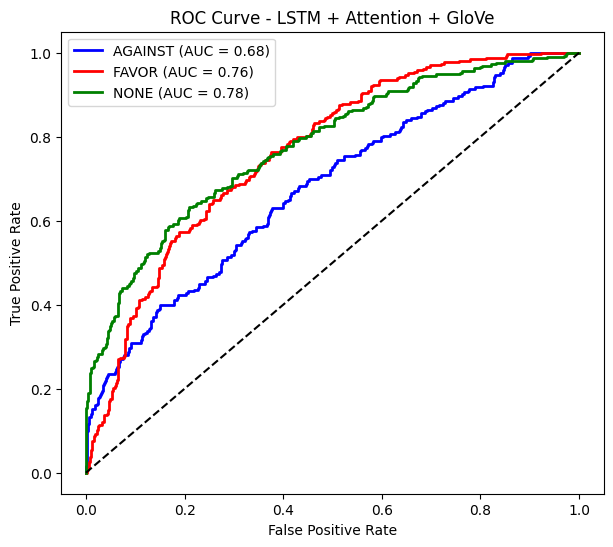

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_val_bin = label_binarize(y_val, classes=[0,1,2])

n_classes = 3

fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC for each class
for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], pred[:, i])

    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(7,6))

colors = ["blue","red","green"]
class_names = ["AGAINST","FAVOR","NONE"]

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

# Random classifier line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - LSTM + Attention + GloVe")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)

precision = precision_score(y_val, y_pred, average="macro")

recall = recall_score(y_val, y_pred, average="macro")

f1 = f1_score(y_val, y_pred, average="macro")
print("Training Time (hours):", training_time)
print("Inference Time (seconds):", inference_time)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
params = model_lstm_attention_glove.count_params()

print("Total Parameters:", params)

print("Parameters (Millions):", params / 1e6)

Training Time (hours): 0.01410386582215627
Inference Time (seconds): 0.7253074645996094
Accuracy: 0.515
Precision: 0.5507765435363955
Recall: 0.5149194384915712
F1 Score: 0.499184873189453
Total Parameters: 243811
Parameters (Millions): 0.243811


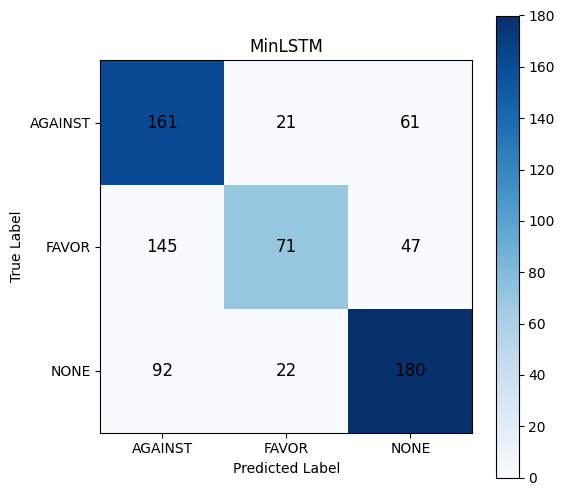

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Class labels
class_names = ["AGAINST", "FAVOR", "NONE"]

# Create matrix with only diagonal values
diag_matrix = np.zeros_like(cm)

for i in range(len(cm)):
    diag_matrix[i, i] = cm[i, i]

# Plot
plt.figure(figsize=(6,6))

# Dark blue diagonal only
plt.imshow(diag_matrix, cmap='Blues', vmin=0, vmax=np.max(cm))

# Add all values (including non-diagonal)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='black',
            fontsize=12
        )

# Axis labels
plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MinLSTM")

plt.grid(False)
plt.colorbar()

plt.show()

**Min GRU + GloVe**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

model_gru_glove = Sequential()

# GloVe Embedding Layer
model_gru_glove.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],   # GloVe vectors
        input_length=max_sequence_length,
        trainable=True
    )
)

# Single GRU Layer
model_gru_glove.add(
    GRU(32)
)

# Output Layer
model_gru_glove.add(
    Dense(3, activation="softmax")
)

# Compile
model_gru_glove.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_gru_glove.summary()

In [ ]:
import time

start_train = time.time()

model_gru_glove.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights
)

end_train = time.time()

training_time = (end_train - start_train) / 3600

In [ ]:
start_inf = time.time()

pred = model_gru_glove.predict(X_val_padded)

end_inf = time.time()

inference_time = end_inf - start_inf

import numpy as np
y_pred = np.argmax(pred, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average="macro")
recall = recall_score(y_val, y_pred, average="macro")
f1 = f1_score(y_val, y_pred, average="macro")

print("Training Time:", training_time)
print("Inference Time:", inference_time)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
params = model_gru_glove.count_params()

print("Total Parameters:", params)

print("Parameters (Millions):", params / 1e6)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels
y_val_bin = label_binarize(y_val, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], pred[:, i])

    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))

colors = ["blue","red","green"]
class_names = ["AGAINST","FAVOR","NONE"]

for i in range(3):

    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - GRU + GloVe")

plt.legend()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Class labels
class_names = ["AGAINST", "FAVOR", "NONE"]

# Keep only diagonal values
diag_matrix = np.zeros_like(cm)

for i in range(len(cm)):
    diag_matrix[i, i] = cm[i, i]

# Plot
plt.figure(figsize=(6,6))

# Dark blue diagonal only
plt.imshow(diag_matrix, cmap='Blues', vmin=0, vmax=np.max(cm))

# Show all values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='black',
            fontsize=12
        )

# Labels
plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - GRU + GloVe")

plt.grid(False)
plt.colorbar()

plt.show()

**min GRU + GloVe + attention**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True
        )

        self.u = self.add_weight(
            shape=(input_shape[-1],),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, inputs):

        score = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)

        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=1),
            axis=1
        )

        context = attention_weights[..., tf.newaxis] * inputs

        context = tf.reduce_sum(context, axis=1)

        return context

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

model_gru_glove_attention = Sequential()

# GloVe Embedding
model_gru_glove_attention.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=True
    )
)

# GRU Layer
model_gru_glove_attention.add(
    GRU(
        32,
        return_sequences=True
    )
)

# Attention
model_gru_glove_attention.add(AttentionLayer())

# Output Layer
model_gru_glove_attention.add(
    Dense(3, activation="softmax")
)

# Compile
model_gru_glove_attention.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_gru_glove_attention.summary()

In [ ]:
import time

start_train = time.time()

model_gru_glove_attention.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights
)

end_train = time.time()

training_time = (end_train - start_train) / 3600

In [ ]:
start_inf = time.time()

pred = model_gru_glove_attention.predict(X_val_padded)

end_inf = time.time()

inference_time = end_inf - start_inf

import numpy as np
y_pred = np.argmax(pred, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average="macro")
recall = recall_score(y_val, y_pred, average="macro")
f1 = f1_score(y_val, y_pred, average="macro")

print("Training Time:", training_time)
print("Inference Time:", inference_time)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
params = model_gru_glove_attention.count_params()

print("Total Parameters:", params)

print("Parameters (Millions):", params / 1e6)

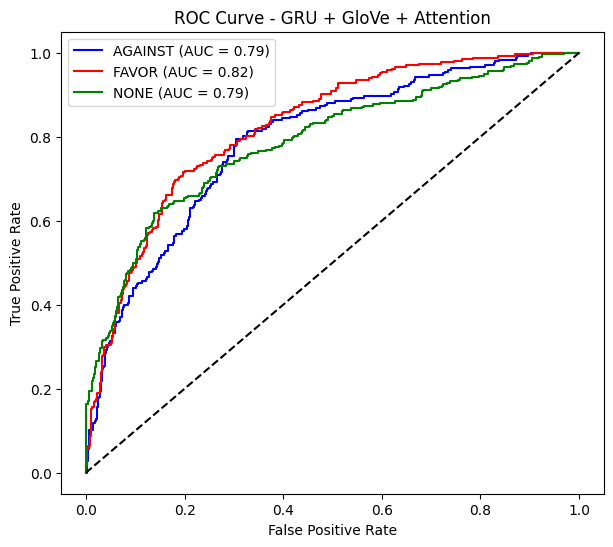

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_val_bin = label_binarize(y_val, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], pred[:, i])

    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))

colors = ["blue","red","green"]
class_names = ["AGAINST","FAVOR","NONE"]

for i in range(3):

    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - GRU + GloVe + Attention")

plt.legend()

plt.show()

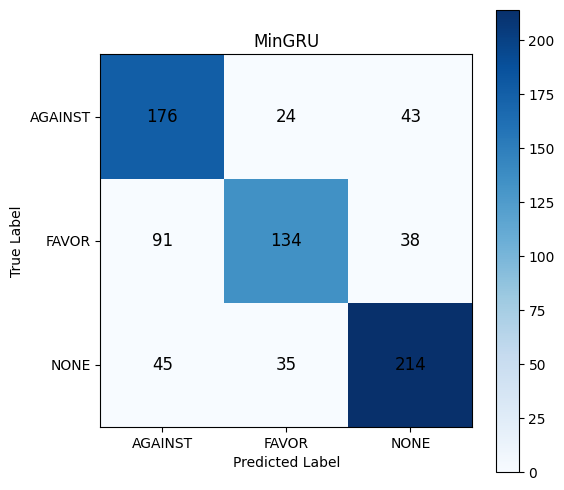

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Class labels
class_names = ["AGAINST", "FAVOR", "NONE"]

# Create diagonal-only matrix
diag_matrix = np.zeros_like(cm)

for i in range(len(cm)):
    diag_matrix[i, i] = cm[i, i]

# Plot
plt.figure(figsize=(6,6))

# Dark blue diagonal only
plt.imshow(diag_matrix, cmap='Blues', vmin=0, vmax=np.max(cm))

# Add all values (including off-diagonal)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='black',
            fontsize=12
        )

# Labels
plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MinGRU")

plt.grid(False)
plt.colorbar()

plt.show()